# Activity Distance LFP: Morlet Coherence Over Distance

This notebook estimates distance-dependent LFP coherence using the Gireesh and Plenz-style logic: Morlet wavelet coefficients are computed for each nested oscillation period, the active cortical site with the largest nLFP deflection is used as the reference, and coherence from that site to all other active sites is binned by distance. A time-shifted segment with the same active sites/reference provides the control.

In [1]:
%matplotlib inline

import json
import os
import sys
import hashlib
import pickle
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str((repo_root / ".mpl-cache").resolve()))

from phase_waves import bandpass_downsample, inspect_file, load_chunk, read_wavefront_cache

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_columns", 120)
np.random.seed(0)


/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Configuration

In [2]:
DIV = 12
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
CACHE_PROFILE = "confirm"
LFP_SOURCE = "stim_removal_null_lfp"
WAVE_INTERVAL_MODE = "burst"

# Wavefront caches define the nested/burst periods and active sites.
CACHE_BAND_LOW = 30.0
CACHE_BAND_HIGH = 50.0
CACHE_FS_DS = 500.0
LAMBDA_MIN = 0.5
LAMBDA_MAX = 10.0
FIT_RADIAL = True

# Gireesh/Plenz-style time-frequency coherence settings.
WAVELET_LOW_HZ = 4.0
WAVELET_HIGH_HZ = 100.0
SUBOCTAVES = 12
MORLET_N_CYCLES = 7.0
COHERENCE_FS_HZ = 500.0
COHERENCE_FILTER_LOW_HZ = 4.0
COHERENCE_FILTER_HIGH_HZ = 120.0
COHERENCE_WINDOW_S = 1.0
PEAK_SEARCH_WINDOW_S = 0.30
SHIFT_CONTROL_S = 5.0

FREQUENCY_BANDS = {
    "theta": (4.0, 8.0),
    "beta": (12.0, 30.0),
    "gamma": (30.0, 100.0),
}

MIN_DISTANCE_UM = 50.0
MAX_DISTANCE_UM = 3500.0
DISTANCE_BIN_UM = 100.0
MAX_EVENTS_PER_WELL = int(os.environ.get("LFP_COH_MAX_EVENTS_PER_WELL", "25"))
MAX_ACTIVE_SITES_PER_EVENT = int(os.environ.get("LFP_COH_MAX_ACTIVE_SITES", "300"))
BOOTSTRAP_REPS = int(os.environ.get("LFP_COH_BOOTSTRAP_REPS", "1000"))
BOOTSTRAP_SEED = 0
FORCE_RECOMPUTE = False
STORE_SITE_ROWS = False

OUTPUT_DIR = repo_root / "outputs" / "lfp_coherence_distance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WAVE_CACHE_DIR = repo_root / "outputs" / "lfp_waves"

CACHE_NOTE = (
    f"{LFP_SOURCE}; {CACHE_PROFILE}; DIV{DIV}; Morlet {WAVELET_LOW_HZ:g}-{WAVELET_HIGH_HZ:g} Hz; "
    f"{SUBOCTAVES} suboctaves; nested-period search={PEAK_SEARCH_WINDOW_S:g}s; shifted={SHIFT_CONTROL_S:g}s"
)


## Cache Paths and Loaders

In [3]:
def dataset_for_well(well):
    return f"data{int(well):04d}"


def wavefront_cache_path(well, *, profile=CACHE_PROFILE):
    label = (
        f"{LFP_SOURCE}_{profile}_well{int(well)}_DIV{int(DIV)}_{dataset_for_well(well)}_{WAVE_INTERVAL_MODE}_"
        f"{CACHE_BAND_LOW:g}-{CACHE_BAND_HIGH:g}Hz_fs{CACHE_FS_DS:g}_lambda{LAMBDA_MIN:g}-{LAMBDA_MAX:g}_radial{int(FIT_RADIAL)}"
    )
    return WAVE_CACHE_DIR / f"wavefront_{label}.h5"


def _as_dataframe(payload, *, well, path, group_name):
    columns = {key: value for key, value in payload.items() if isinstance(value, np.ndarray) and np.asarray(value).ndim > 0}
    if not columns:
        return pd.DataFrame()
    lengths = {key: len(value) for key, value in columns.items()}
    n = next(iter(lengths.values()))
    keep = {key: np.asarray(value) for key, value in columns.items() if len(value) == n}
    frame = pd.DataFrame(keep)
    frame.insert(0, "well", int(well))
    frame.insert(1, "cache_path", str(path))
    frame.insert(2, "group_name", group_name)
    return frame


def load_wavefront_tables(wells, *, profile=CACHE_PROFILE):
    event_parts = []
    local_parts = []
    summary_rows = []
    missing = []
    for well in wells:
        path = wavefront_cache_path(well, profile=profile)
        if not path.exists():
            fallback = wavefront_cache_path(well, profile="permissive")
            if profile != "permissive" and fallback.exists():
                print(f"well {well}: missing {profile} cache; using permissive fallback")
                path = fallback
            else:
                missing.append({"well": int(well), "path": str(path), "reason": "missing cache"})
                continue
        cache = read_wavefront_cache(path)
        if "wavefront_events" not in cache or "wavefront_local" not in cache:
            missing.append({"well": int(well), "path": str(path), "reason": "missing groups"})
            continue
        event = _as_dataframe(cache["wavefront_events"], well=well, path=path, group_name="wavefront_events")
        local = _as_dataframe(cache["wavefront_local"], well=well, path=path, group_name="wavefront_local")
        if local.empty:
            missing.append({"well": int(well), "path": str(path), "reason": "empty local table"})
            continue
        if "valid" in local:
            local["valid"] = local["valid"].astype(bool)
        if "front_valid" in event:
            event["front_valid"] = event["front_valid"].astype(bool)
        cfg = {}
        if "wavefront_calibration" in cache and cache["wavefront_calibration"].get("config"):
            cfg = json.loads(cache["wavefront_calibration"].get("config"))
        event["raw_file"] = cfg.get("file", "")
        event["dataset"] = cfg.get("dataset", dataset_for_well(well))
        local["raw_file"] = cfg.get("file", "")
        local["dataset"] = cfg.get("dataset", dataset_for_well(well))
        event_parts.append(event)
        local_parts.append(local)
        summary_rows.append({
            "well": int(well),
            "cache_path": str(path),
            "profile": cfg.get("profile", profile),
            "raw_file": cfg.get("file", ""),
            "dataset": cfg.get("dataset", dataset_for_well(well)),
            "n_events": int(event["event_idx"].nunique()) if "event_idx" in event else int(len(event)),
            "n_local_rows": int(len(local)),
            "n_finite_crossings": int(np.isfinite(local["arrival_time_s"]).sum()),
            "n_valid_sources": int(local["valid"].sum()) if "valid" in local else 0,
        })
    event_df = pd.concat(event_parts, ignore_index=True) if event_parts else pd.DataFrame()
    local_df = pd.concat(local_parts, ignore_index=True) if local_parts else pd.DataFrame()
    cache_summary = pd.DataFrame(summary_rows)
    missing_df = pd.DataFrame(missing)
    return event_df, local_df, cache_summary, missing_df


event_df, local_df, cache_summary, missing_cache_df = load_wavefront_tables(AGGREGATE_WELLS)
display(cache_summary)
if not missing_cache_df.empty:
    display(missing_cache_df)
print(f"Loaded events={len(event_df):,}; local rows={len(local_df):,}; wells={cache_summary['well'].nunique() if not cache_summary.empty else 0}")


,well,cache_path,profile,raw_file,dataset,n_events,n_local_rows,n_finite_crossings,n_valid_sources
0,0,/Users/danielrebbin/Documents/GitHub/ephax/out...,confirm,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,174,177480,113865,87233
1,1,/Users/danielrebbin/Documents/GitHub/ephax/out...,confirm,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0001,189,192780,122999,95569
2,2,/Users/danielrebbin/Documents/GitHub/ephax/out...,confirm,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0002,200,203600,128914,97737
3,3,/Users/danielrebbin/Documents/GitHub/ephax/out...,confirm,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0003,180,183600,119193,93884
4,4,/Users/danielrebbin/Documents/GitHub/ephax/out...,confirm,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0004,148,150960,96762,74958
5,5,/Users/danielrebbin/Documents/GitHub/ephax/out...,confirm,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0005,173,176460,112940,86716


Loaded events=1,064; local rows=1,084,880; wells=6


## Morlet Coherence Over Distance

In [4]:
def distance_edges_and_centers():
    edges = np.arange(MIN_DISTANCE_UM, MAX_DISTANCE_UM + DISTANCE_BIN_UM, DISTANCE_BIN_UM, dtype=float)
    if edges[-1] < MAX_DISTANCE_UM:
        edges = np.append(edges, MAX_DISTANCE_UM)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers


def morlet_frequencies(low_hz=WAVELET_LOW_HZ, high_hz=WAVELET_HIGH_HZ, suboctaves=SUBOCTAVES):
    exponents = np.arange(np.log2(float(low_hz)), np.log2(float(high_hz)) + 1e-9, 1.0 / int(suboctaves))
    freqs = 2.0 ** exponents
    return freqs[freqs <= float(high_hz) * (1.0 + 1e-9)]


WAVELET_FREQS_HZ = morlet_frequencies()
print(f"Morlet frequencies: {len(WAVELET_FREQS_HZ)} bins from {WAVELET_FREQS_HZ[0]:.2f} to {WAVELET_FREQS_HZ[-1]:.2f} Hz")


def analysis_cache_key():
    payload = {
        "cache_paths": sorted(cache_summary["cache_path"].tolist()) if not cache_summary.empty else [],
        "profile": CACHE_PROFILE,
        "wavelet_freqs": np.round(WAVELET_FREQS_HZ, 6).tolist(),
        "bands": FREQUENCY_BANDS,
        "window_s": float(COHERENCE_WINDOW_S),
        "peak_search_window_s": float(PEAK_SEARCH_WINDOW_S),
        "nested_period_coherence": True,
        "shift_s": float(SHIFT_CONTROL_S),
        "fs_hz": float(COHERENCE_FS_HZ),
        "filter": [float(COHERENCE_FILTER_LOW_HZ), float(COHERENCE_FILTER_HIGH_HZ)],
        "distance": [float(MIN_DISTANCE_UM), float(MAX_DISTANCE_UM), float(DISTANCE_BIN_UM)],
        "max_events_per_well": None if MAX_EVENTS_PER_WELL is None else int(MAX_EVENTS_PER_WELL),
        "max_active_sites": None if MAX_ACTIVE_SITES_PER_EVENT is None else int(MAX_ACTIVE_SITES_PER_EVENT),
        "store_site_rows": bool(STORE_SITE_ROWS),
    }
    text = json.dumps(payload, sort_keys=True)
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:16]


ANALYSIS_CACHE_PATH = OUTPUT_DIR / f"lfp_morlet_site_coherence_{analysis_cache_key()}.pkl"
ANALYSIS_CACHE_PATH


Morlet frequencies: 56 bins from 4.00 to 95.89 Hz


PosixPath('/Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/lfp_morlet_site_coherence_91f6b7668338c84d.pkl')

In [5]:
def _deterministic_subset(values, max_n):
    values = np.asarray(values)
    if max_n is None or values.size <= int(max_n):
        return values
    pick = np.round(np.linspace(0, values.size - 1, int(max_n))).astype(int)
    return values[pick]


def _select_events_for_well(event_table):
    valid = event_table.copy()
    if "front_valid" in valid:
        valid = valid.loc[valid["front_valid"].astype(bool)].copy()
    valid = valid.sort_values("anchor_time_s").reset_index(drop=True)
    if valid.empty:
        return valid
    if MAX_EVENTS_PER_WELL is None or len(valid) <= int(MAX_EVENTS_PER_WELL):
        return valid
    idx = np.round(np.linspace(0, len(valid) - 1, int(MAX_EVENTS_PER_WELL))).astype(int)
    return valid.iloc[idx].reset_index(drop=True)


def _active_electrodes_for_event(local_group):
    group = local_group.copy()
    keep = np.isfinite(group["arrival_time_s"].to_numpy(float))
    if "arrival_amplitude" in group:
        group = group.loc[keep].sort_values("arrival_amplitude", ascending=False)
    else:
        group = group.loc[keep].sort_values("electrode")
    electrodes = group["electrode"].drop_duplicates().to_numpy(int)
    return _deterministic_subset(electrodes, MAX_ACTIVE_SITES_PER_EVENT).astype(int)


def _mapping_for_recording(raw_file, dataset):
    _, _, _, mapping = load_chunk(raw_file, dataset, 0, 1)
    return {
        "channel": np.asarray(mapping["channel"], dtype=int),
        "electrode": np.asarray(mapping["electrode"], dtype=int),
        "x_um": np.asarray(mapping["x"], dtype=float),
        "y_um": np.asarray(mapping["y"], dtype=float),
    }


def _channels_for_electrodes(raw_file, dataset, electrodes):
    mapping = _mapping_for_recording(raw_file, dataset)
    frame = pd.DataFrame(mapping)
    requested = pd.DataFrame({"electrode": np.asarray(electrodes, dtype=int)})
    merged = requested.merge(frame, on="electrode", how="inner")
    return merged.drop_duplicates("electrode").reset_index(drop=True)


def _load_lfp_segment(raw_file, dataset, anchor_s, electrodes, *, shift_s=0.0):
    info = inspect_file(raw_file, dataset)
    fs_raw = float(info["fs_raw"])
    recording_stop_s = float(info["raw_shape"][1]) / fs_raw
    center_s = float(anchor_s) + float(shift_s)
    half = 0.5 * float(COHERENCE_WINDOW_S)
    start_s = center_s - half
    stop_s = center_s + half
    if start_s < 0 or stop_s > recording_stop_s:
        return None
    channel_table = _channels_for_electrodes(raw_file, dataset, electrodes)
    if channel_table.empty or len(channel_table) < 2:
        return None
    start_frame = int(round(start_s * fs_raw))
    n_frames = max(1, int(round((stop_s - start_s) * fs_raw)))
    raw, coords_mm, fs_loaded, mapping = load_chunk(
        raw_file,
        dataset,
        start_frame,
        n_frames,
        channels=channel_table["channel"].to_numpy(int),
    )
    if raw.shape[0] < 8 or raw.shape[1] < 2:
        return None
    band = bandpass_downsample(
        raw,
        fs_loaded,
        COHERENCE_FILTER_LOW_HZ,
        COHERENCE_FILTER_HIGH_HZ,
        COHERENCE_FS_HZ,
        max_channels_per_block=128,
    )
    electrodes_loaded = np.asarray(mapping["electrode"], dtype=int)
    channels_loaded = np.asarray(mapping["channel"], dtype=int)
    coords_um = np.column_stack([np.asarray(mapping["x"], dtype=float), np.asarray(mapping["y"], dtype=float)])
    t_s = start_s + np.arange(band.shape[0], dtype=float) / float(COHERENCE_FS_HZ)
    return {
        "data": band.astype(np.float32, copy=False),
        "t_s": t_s,
        "coords_um": coords_um,
        "electrodes": electrodes_loaded,
        "channels": channels_loaded,
        "start_s": start_s,
        "stop_s": stop_s,
    }


In [6]:
def morlet_coefficients(traces, fs_hz, freqs_hz, *, n_cycles=MORLET_N_CYCLES):
    x = np.asarray(traces, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError("traces must be samples x channels")
    x = x - np.nanmean(x, axis=0, keepdims=True)
    x = np.nan_to_num(x, copy=False)
    coeffs = np.empty((len(freqs_hz), x.shape[0], x.shape[1]), dtype=np.complex64)
    for fi, freq_hz in enumerate(np.asarray(freqs_hz, dtype=float)):
        sigma_t = float(n_cycles) / (2.0 * np.pi * float(freq_hz))
        half_width = max(3, int(np.ceil(4.0 * sigma_t * float(fs_hz))))
        tau = np.arange(-half_width, half_width + 1, dtype=float) / float(fs_hz)
        wavelet = np.exp(2j * np.pi * float(freq_hz) * tau) * np.exp(-(tau ** 2) / (2.0 * sigma_t ** 2))
        wavelet /= np.sqrt(np.sum(np.abs(wavelet) ** 2))
        coeffs[fi] = fftconvolve(x, np.conj(wavelet[::-1, None]), mode="same", axes=0).astype(np.complex64, copy=False)
    return coeffs


def largest_nlfp_reference(data):
    # nLFP events are negative deflections; use the largest negative excursion in the period.
    negative_peak = -np.nanmin(np.asarray(data, dtype=float), axis=0)
    if not np.any(np.isfinite(negative_peak)):
        return None
    return int(np.nanargmax(negative_peak))


def _band_frequency_mask(band):
    low, high = map(float, band)
    return (WAVELET_FREQS_HZ >= low) & (WAVELET_FREQS_HZ <= high)


def _band_peak_period(coeffs, ref_idx, band, t_s, *, center_s=None, spec=None):
    mask_freq = _band_frequency_mask(band)
    freq_idx = np.flatnonzero(mask_freq)
    if freq_idx.size == 0:
        return None

    t_s = np.asarray(t_s, dtype=float)
    if spec is None:
        if center_s is None:
            center_s = 0.5 * (t_s[0] + t_s[-1])
        half_search = 0.5 * float(PEAK_SEARCH_WINDOW_S)
        mask_time = (t_s >= center_s - half_search) & (t_s <= center_s + half_search)
        if not np.any(mask_time):
            mask_time = np.ones(t_s.size, dtype=bool)
        time_idx = np.flatnonzero(mask_time)
        ref_power = np.abs(coeffs[freq_idx[:, None], time_idx[None, :], int(ref_idx)]) ** 2
        best_flat = int(np.nanargmax(ref_power))
        best_f_local, best_t_local = np.unravel_index(best_flat, ref_power.shape)
        peak_freq_idx = int(freq_idx[best_f_local])
        peak_time_idx = int(time_idx[best_t_local])
        peak_freq_hz = float(WAVELET_FREQS_HZ[peak_freq_idx])
        center_offset_s = float(t_s[peak_time_idx] - center_s)
    else:
        peak_freq_hz = float(spec["peak_frequency_hz"])
        peak_freq_idx = int(np.nanargmin(np.abs(WAVELET_FREQS_HZ - peak_freq_hz)))
        center_offset_s = float(spec["center_offset_s"])
        if center_s is None:
            center_s = 0.5 * (t_s[0] + t_s[-1])
        peak_time_idx = int(np.nanargmin(np.abs(t_s - (float(center_s) + center_offset_s))))

    half_period = 0.5 / max(peak_freq_hz, np.finfo(float).eps)
    peak_time_s = float(t_s[peak_time_idx])
    period_mask = np.abs(t_s - peak_time_s) <= half_period
    if np.sum(period_mask) < 3:
        nearest = np.argsort(np.abs(t_s - peak_time_s))[:3]
        period_mask = np.zeros(t_s.size, dtype=bool)
        period_mask[nearest] = True

    return {
        "freq_idx": peak_freq_idx,
        "peak_frequency_hz": peak_freq_hz,
        "peak_time_s": peak_time_s,
        "center_offset_s": center_offset_s,
        "period_start_s": float(np.nanmin(t_s[period_mask])),
        "period_stop_s": float(np.nanmax(t_s[period_mask])),
        "period_duration_s": float(np.nanmax(t_s[period_mask]) - np.nanmin(t_s[period_mask]) + 1.0 / COHERENCE_FS_HZ),
        "period_mask": period_mask,
    }


def coherence_from_reference_period(coeffs, ref_idx, freq_mask, time_mask):
    freq_idx = np.flatnonzero(freq_mask)
    time_idx = np.flatnonzero(time_mask)
    if freq_idx.size == 0 or time_idx.size == 0:
        return np.full(coeffs.shape[2], np.nan, dtype=float)
    sub = coeffs[freq_idx[:, None, None], time_idx[None, :, None], np.arange(coeffs.shape[2])[None, None, :]]
    ref = coeffs[freq_idx[:, None], time_idx[None, :], int(ref_idx)]
    cross = np.nanmean(ref[:, :, None] * np.conj(sub), axis=(0, 1))
    ref_power = np.nanmean(np.abs(ref) ** 2)
    tgt_power = np.nanmean(np.abs(sub) ** 2, axis=(0, 1))
    denom = np.sqrt(ref_power * tgt_power)
    coh = np.abs(cross) / np.maximum(denom, np.finfo(float).tiny)
    return np.clip(np.asarray(coh, dtype=float), 0.0, 1.0)


def _band_site_power(coeffs, band, time_mask):
    freq_mask = _band_frequency_mask(band)
    if not np.any(freq_mask) or not np.any(time_mask):
        return np.full(coeffs.shape[2], np.nan, dtype=float)
    return np.nanmean(np.abs(coeffs[freq_mask][:, time_mask, :]) ** 2, axis=(0, 1))


def _event_condition_rows(segment, *, well, event_idx, anchor_time_s, condition, ref_electrode=None, period_specs=None):
    data = segment["data"]
    if ref_electrode is None:
        ref_idx = largest_nlfp_reference(data)
    else:
        matches = np.flatnonzero(segment["electrodes"] == int(ref_electrode))
        ref_idx = int(matches[0]) if matches.size else None
    if ref_idx is None or data.shape[1] < 2:
        return [], [], [], [], None, {}

    coeffs = morlet_coefficients(data, COHERENCE_FS_HZ, WAVELET_FREQS_HZ)
    coords = np.asarray(segment["coords_um"], dtype=float)
    ref_coord = coords[ref_idx]
    distance_um = np.sqrt(np.sum((coords - ref_coord[None, :]) ** 2, axis=1))
    not_ref = np.arange(coords.shape[0]) != ref_idx
    edges, centers = distance_edges_and_centers()
    bin_idx = np.searchsorted(edges, distance_um, side="right") - 1
    keep_site = not_ref & (bin_idx >= 0) & (bin_idx < centers.size) & np.isfinite(distance_um)
    segment_center_s = 0.5 * (float(segment["start_s"]) + float(segment["stop_s"]))

    rows = []
    site_rows = []
    spectrum_rows = []
    power_rows = []
    out_specs = {}

    for band_name, band in FREQUENCY_BANDS.items():
        spec_in = None if period_specs is None else period_specs.get(band_name)
        period = _band_peak_period(coeffs, ref_idx, band, segment["t_s"], center_s=segment_center_s, spec=spec_in)
        if period is None:
            continue
        out_specs[band_name] = {k: v for k, v in period.items() if k != "period_mask"}
        freq_mask = _band_frequency_mask(band)
        site_coh = coherence_from_reference_period(coeffs, ref_idx, freq_mask, period["period_mask"])
        keep = keep_site & np.isfinite(site_coh)
        for b in np.unique(bin_idx[keep]):
            vals = site_coh[keep & (bin_idx == b)]
            if vals.size == 0:
                continue
            rows.append({
                "well": int(well),
                "event_idx": int(event_idx),
                "condition": str(condition),
                "band": str(band_name),
                "distance_bin_idx": int(b),
                "distance_bin_center_um": float(centers[int(b)]),
                "coherence": float(np.nanmean(vals)),
                "n_sites": int(vals.size),
                "ref_electrode": int(segment["electrodes"][ref_idx]),
                "anchor_time_s": float(anchor_time_s),
                "segment_start_s": float(segment["start_s"]),
                "segment_stop_s": float(segment["stop_s"]),
                "peak_frequency_hz": float(period["peak_frequency_hz"]),
                "peak_time_s": float(period["peak_time_s"]),
                "period_start_s": float(period["period_start_s"]),
                "period_stop_s": float(period["period_stop_s"]),
                "period_duration_s": float(period["period_duration_s"]),
            })
        if STORE_SITE_ROWS:
            for idx in np.flatnonzero(keep):
                site_rows.append({
                    "well": int(well),
                    "event_idx": int(event_idx),
                    "condition": str(condition),
                    "band": str(band_name),
                    "distance_um": float(distance_um[idx]),
                    "distance_bin_idx": int(bin_idx[idx]),
                    "distance_bin_center_um": float(centers[int(bin_idx[idx])]),
                    "coherence": float(site_coh[idx]),
                    "ref_electrode": int(segment["electrodes"][ref_idx]),
                    "target_electrode": int(segment["electrodes"][idx]),
                    "peak_frequency_hz": float(period["peak_frequency_hz"]),
                })
        if band_name == "gamma" and condition == "burst":
            gamma_power = _band_site_power(coeffs, band, period["period_mask"])
            order = np.argsort(np.nan_to_num(gamma_power, nan=-np.inf))[::-1]
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, order.size + 1)
            for idx, power in enumerate(gamma_power):
                if not np.isfinite(power):
                    continue
                power_rows.append({
                    "well": int(well),
                    "event_idx": int(event_idx),
                    "condition": str(condition),
                    "electrode": int(segment["electrodes"][idx]),
                    "x_um": float(coords[idx, 0]),
                    "y_um": float(coords[idx, 1]),
                    "distance_um": float(distance_um[idx]),
                    "gamma_power": float(power),
                    "gamma_power_rank": int(ranks[idx]),
                    "is_ref_electrode": bool(idx == ref_idx),
                    "ref_electrode": int(segment["electrodes"][ref_idx]),
                    "peak_frequency_hz": float(period["peak_frequency_hz"]),
                    "peak_time_s": float(period["peak_time_s"]),
                })

    keep = keep_site
    if np.any(keep):
        for freq_idx, freq_hz in enumerate(WAVELET_FREQS_HZ):
            period = _band_peak_period(coeffs, ref_idx, (freq_hz, freq_hz), segment["t_s"], center_s=segment_center_s)
            if period is None:
                continue
            site_coh = coherence_from_reference_period(coeffs, ref_idx, np.arange(len(WAVELET_FREQS_HZ)) == freq_idx, period["period_mask"])
            spectrum_rows.append({
                "well": int(well),
                "event_idx": int(event_idx),
                "condition": str(condition),
                "frequency_hz": float(freq_hz),
                "coherence": float(np.nanmean(site_coh[keep])),
                "n_sites": int(np.sum(keep)),
                "ref_electrode": int(segment["electrodes"][ref_idx]),
                "anchor_time_s": float(anchor_time_s),
            })
    return rows, site_rows, spectrum_rows, power_rows, int(segment["electrodes"][ref_idx]), out_specs


In [7]:
def compute_wavelet_distance_coherence(event_df, local_df):
    distance_rows = []
    site_rows = []
    spectrum_rows = []
    gamma_power_rows = []
    selected_events = []
    if event_df.empty or local_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    for well, well_events in event_df.groupby("well", sort=True):
        well_selected = _select_events_for_well(well_events)
        local_well = local_df.loc[local_df["well"] == int(well)]
        for _, event in well_selected.iterrows():
            event_idx = int(event["event_idx"])
            local_group = local_well.loc[local_well["event_idx"] == event_idx]
            electrodes = _active_electrodes_for_event(local_group)
            if electrodes.size < 2:
                continue
            raw_file = str(event["raw_file"])
            dataset = str(event["dataset"])
            anchor_s = float(event["anchor_time_s"])

            burst_segment = _load_lfp_segment(raw_file, dataset, anchor_s, electrodes, shift_s=0.0)
            if burst_segment is None:
                continue
            burst_rows, burst_site_rows, burst_spectrum, burst_gamma_power, ref_electrode, period_specs = _event_condition_rows(
                burst_segment,
                well=well,
                event_idx=event_idx,
                anchor_time_s=anchor_s,
                condition="burst",
            )
            if ref_electrode is None:
                continue
            distance_rows.extend(burst_rows)
            site_rows.extend(burst_site_rows)
            spectrum_rows.extend(burst_spectrum)
            gamma_power_rows.extend(burst_gamma_power)

            shifted_segment = _load_lfp_segment(raw_file, dataset, anchor_s, electrodes, shift_s=SHIFT_CONTROL_S)
            if shifted_segment is not None:
                shifted_rows, shifted_site_rows, shifted_spectrum, _, _, _ = _event_condition_rows(
                    shifted_segment,
                    well=well,
                    event_idx=event_idx,
                    anchor_time_s=anchor_s,
                    condition="shifted",
                    ref_electrode=ref_electrode,
                    period_specs=period_specs,
                )
                distance_rows.extend(shifted_rows)
                site_rows.extend(shifted_site_rows)
                spectrum_rows.extend(shifted_spectrum)

            selected_events.append({
                "well": int(well),
                "event_idx": event_idx,
                "anchor_time_s": anchor_s,
                "raw_file": raw_file,
                "dataset": dataset,
                "n_active_electrodes": int(electrodes.size),
                "ref_electrode": int(ref_electrode),
                "theta_peak_frequency_hz": period_specs.get("theta", {}).get("peak_frequency_hz", np.nan),
                "beta_peak_frequency_hz": period_specs.get("beta", {}).get("peak_frequency_hz", np.nan),
                "gamma_peak_frequency_hz": period_specs.get("gamma", {}).get("peak_frequency_hz", np.nan),
            })
        print(f"well {well}: processed {len([r for r in selected_events if r['well'] == int(well)])} events")

    return (
        pd.DataFrame(distance_rows),
        pd.DataFrame(site_rows),
        pd.DataFrame(spectrum_rows),
        pd.DataFrame(gamma_power_rows),
        pd.DataFrame(selected_events),
    )


if ANALYSIS_CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with ANALYSIS_CACHE_PATH.open("rb") as f:
        cached = pickle.load(f)
    event_distance_coherence = cached["event_distance_coherence"]
    lfp_site_coherence = cached.get("lfp_site_coherence", pd.DataFrame())
    frequency_coherence = cached.get("frequency_coherence", pd.DataFrame())
    gamma_site_power = cached.get("gamma_site_power", pd.DataFrame())
    selected_event_table = cached.get("selected_event_table", pd.DataFrame())
    print(f"Loaded cached Morlet LFP coherence: {ANALYSIS_CACHE_PATH}")
else:
    event_distance_coherence, lfp_site_coherence, frequency_coherence, gamma_site_power, selected_event_table = compute_wavelet_distance_coherence(event_df, local_df)
    with ANALYSIS_CACHE_PATH.open("wb") as f:
        pickle.dump({
            "event_distance_coherence": event_distance_coherence,
            "lfp_site_coherence": lfp_site_coherence,
            "frequency_coherence": frequency_coherence,
            "gamma_site_power": gamma_site_power,
            "selected_event_table": selected_event_table,
            "cache_summary": cache_summary,
        }, f)
    print(f"Wrote Morlet LFP coherence cache: {ANALYSIS_CACHE_PATH}")

print("event_distance_coherence", event_distance_coherence.shape)
print("frequency_coherence", frequency_coherence.shape)
print("gamma_site_power", gamma_site_power.shape)
print("selected events", selected_event_table.shape)
display(event_distance_coherence.head())
display(selected_event_table.head())


Loaded cached Morlet LFP coherence: /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/lfp_morlet_site_coherence_91f6b7668338c84d.pkl
event_distance_coherence (1002, 17)
frequency_coherence (672, 8)
gamma_site_power (480, 13)
selected events (6, 10)


,well,event_idx,condition,band,distance_bin_idx,distance_bin_center_um,coherence,n_sites,ref_electrode,anchor_time_s,segment_start_s,segment_stop_s,peak_frequency_hz,peak_time_s,period_start_s,period_stop_s,period_duration_s
0,0,0,burst,theta,1,200.0,0.910202,2,23603,16.0215,15.5215,16.5215,5.656854,16.1715,16.0835,16.2595,0.178
1,0,0,burst,theta,3,400.0,0.608578,2,23603,16.0215,15.5215,16.5215,5.656854,16.1715,16.0835,16.2595,0.178
2,0,0,burst,theta,4,500.0,0.892362,3,23603,16.0215,15.5215,16.5215,5.656854,16.1715,16.0835,16.2595,0.178
3,0,0,burst,theta,5,600.0,0.890467,3,23603,16.0215,15.5215,16.5215,5.656854,16.1715,16.0835,16.2595,0.178
4,0,0,burst,theta,6,700.0,0.511255,3,23603,16.0215,15.5215,16.5215,5.656854,16.1715,16.0835,16.2595,0.178


,well,event_idx,anchor_time_s,raw_file,dataset,n_active_electrodes,ref_electrode,theta_peak_frequency_hz,beta_peak_frequency_hz,gamma_peak_frequency_hz
0,0,0,16.0215,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0000,80,23603,5.656854,25.398417,30.203978
1,1,0,25.7995,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0001,80,24443,7.550995,12.699208,30.203978
2,2,0,7.4185,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0002,80,6559,5.656854,12.699208,30.203978
3,3,0,2.5455,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0003,80,20909,7.550995,12.699208,40.317474
4,4,0,8.9235,/Users/danielrebbin/Documents/Academia/UvA/Int...,data0004,80,25421,7.550995,20.158737,42.714875


## Summaries

In [8]:
def bootstrap_ci(values, reps=BOOTSTRAP_REPS, seed=BOOTSTRAP_SEED, statistic=np.nanmean):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(int(seed))
    boot = np.array([statistic(rng.choice(values, size=values.size, replace=True)) for _ in range(int(reps))])
    return tuple(np.nanpercentile(boot, [2.5, 50.0, 97.5]))


def summarize_condition_distance(event_distance):
    rows = []
    group_cols = ["condition", "band", "well", "distance_bin_center_um"]
    for key, group in event_distance.groupby(group_cols, sort=True):
        condition, band, well, distance = key
        lo, med, hi = bootstrap_ci(group["coherence"].to_numpy(float), seed=BOOTSTRAP_SEED + int(well))
        rows.append({
            "condition": condition,
            "band": band,
            "well": int(well),
            "distance_bin_center_um": float(distance),
            "coherence_mean": float(np.nanmean(group["coherence"])),
            "coherence_median": float(np.nanmedian(group["coherence"])),
            "coherence_ci_low": lo,
            "coherence_ci_high": hi,
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
            "n_sites_total": int(group["n_sites"].sum()),
        })
    return pd.DataFrame(rows)


def compute_relative_event_distance(event_distance):
    if event_distance.empty:
        return pd.DataFrame()
    key = ["well", "event_idx", "band", "distance_bin_center_um"]
    pivot = event_distance.pivot_table(index=key, columns="condition", values="coherence", aggfunc="mean").reset_index()
    if "burst" not in pivot or "shifted" not in pivot:
        return pd.DataFrame()
    pivot = pivot[np.isfinite(pivot["burst"]) & np.isfinite(pivot["shifted"]) & (pivot["shifted"] > 0)].copy()
    pivot["coherence_relative"] = pivot["burst"] / pivot["shifted"]
    return pivot


def hierarchical_relative_summary(relative_df):
    rows = []
    if relative_df.empty:
        return pd.DataFrame()
    rng = np.random.default_rng(int(BOOTSTRAP_SEED) + 2000)
    wells = np.asarray(sorted(relative_df["well"].unique()), dtype=int)
    for (band, distance), group in relative_df.groupby(["band", "distance_bin_center_um"], sort=True):
        observed = group.groupby("well")["coherence_relative"].mean().mean()
        boot = []
        for _ in range(int(BOOTSTRAP_REPS)):
            sampled_wells = rng.choice(wells, size=wells.size, replace=True)
            sampled_values = []
            for well in sampled_wells:
                values = group.loc[group["well"] == well, "coherence_relative"].to_numpy(float)
                values = values[np.isfinite(values)]
                if values.size:
                    sampled_values.append(np.nanmean(rng.choice(values, size=values.size, replace=True)))
            if sampled_values:
                boot.append(np.nanmean(sampled_values))
        lo, med, hi = np.nanpercentile(boot, [2.5, 50.0, 97.5]) if boot else (np.nan, np.nan, np.nan)
        rows.append({
            "band": str(band),
            "distance_bin_center_um": float(distance),
            "coherence_relative_mean": float(observed),
            "coherence_relative_bootstrap_median": float(med),
            "coherence_relative_ci_low": float(lo),
            "coherence_relative_ci_high": float(hi),
            "n_wells": int(group["well"].nunique()),
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


def summarize_frequency_coherence(freq_df):
    if freq_df.empty:
        return pd.DataFrame()
    rows = []
    for (condition, frequency), group in freq_df.groupby(["condition", "frequency_hz"], sort=True):
        rows.append({
            "condition": condition,
            "frequency_hz": float(frequency),
            "coherence_mean": float(np.nanmean(group["coherence"])),
            "coherence_median": float(np.nanmedian(group["coherence"])),
            "n_events": int(group[["well", "event_idx"]].drop_duplicates().shape[0]),
        })
    return pd.DataFrame(rows)


condition_distance_summary = summarize_condition_distance(event_distance_coherence)
relative_event_distance = compute_relative_event_distance(event_distance_coherence)
relative_distance_summary = hierarchical_relative_summary(relative_event_distance)
frequency_summary = summarize_frequency_coherence(frequency_coherence)

display(condition_distance_summary.head())
display(relative_distance_summary.head())
display(frequency_summary.head())


,condition,band,well,distance_bin_center_um,coherence_mean,coherence_median,coherence_ci_low,coherence_ci_high,n_events,n_sites_total
0,burst,beta,0,200.0,0.709266,0.709266,0.709266,0.709266,1,2
1,burst,beta,0,400.0,0.484852,0.484852,0.484852,0.484852,1,2
2,burst,beta,0,500.0,0.693928,0.693928,0.693928,0.693928,1,3
3,burst,beta,0,600.0,0.537276,0.537276,0.537276,0.537276,1,3
4,burst,beta,0,700.0,0.791198,0.791198,0.791198,0.791198,1,3


,band,distance_bin_center_um,coherence_relative_mean,coherence_relative_bootstrap_median,coherence_relative_ci_low,coherence_relative_ci_high,n_wells,n_events
0,beta,100.0,1.536140,1.536140,0.998427,2.073853,2,2
1,beta,200.0,1.551533,1.477206,1.011096,2.090577,4,4
2,beta,300.0,1.661258,1.610715,1.241811,2.066285,4,4
3,beta,400.0,1.178865,1.213707,0.928063,1.588138,5,5
4,beta,500.0,1.528028,1.527652,1.253596,1.858532,5,5


,condition,frequency_hz,coherence_mean,coherence_median,n_events
0,burst,4.000000,0.954855,0.956015,6
1,burst,4.237852,0.954653,0.955453,6
2,burst,4.489848,0.956843,0.959216,6
3,burst,4.756828,0.964502,0.964224,6
4,burst,5.039684,0.964175,0.968531,6


## Plots

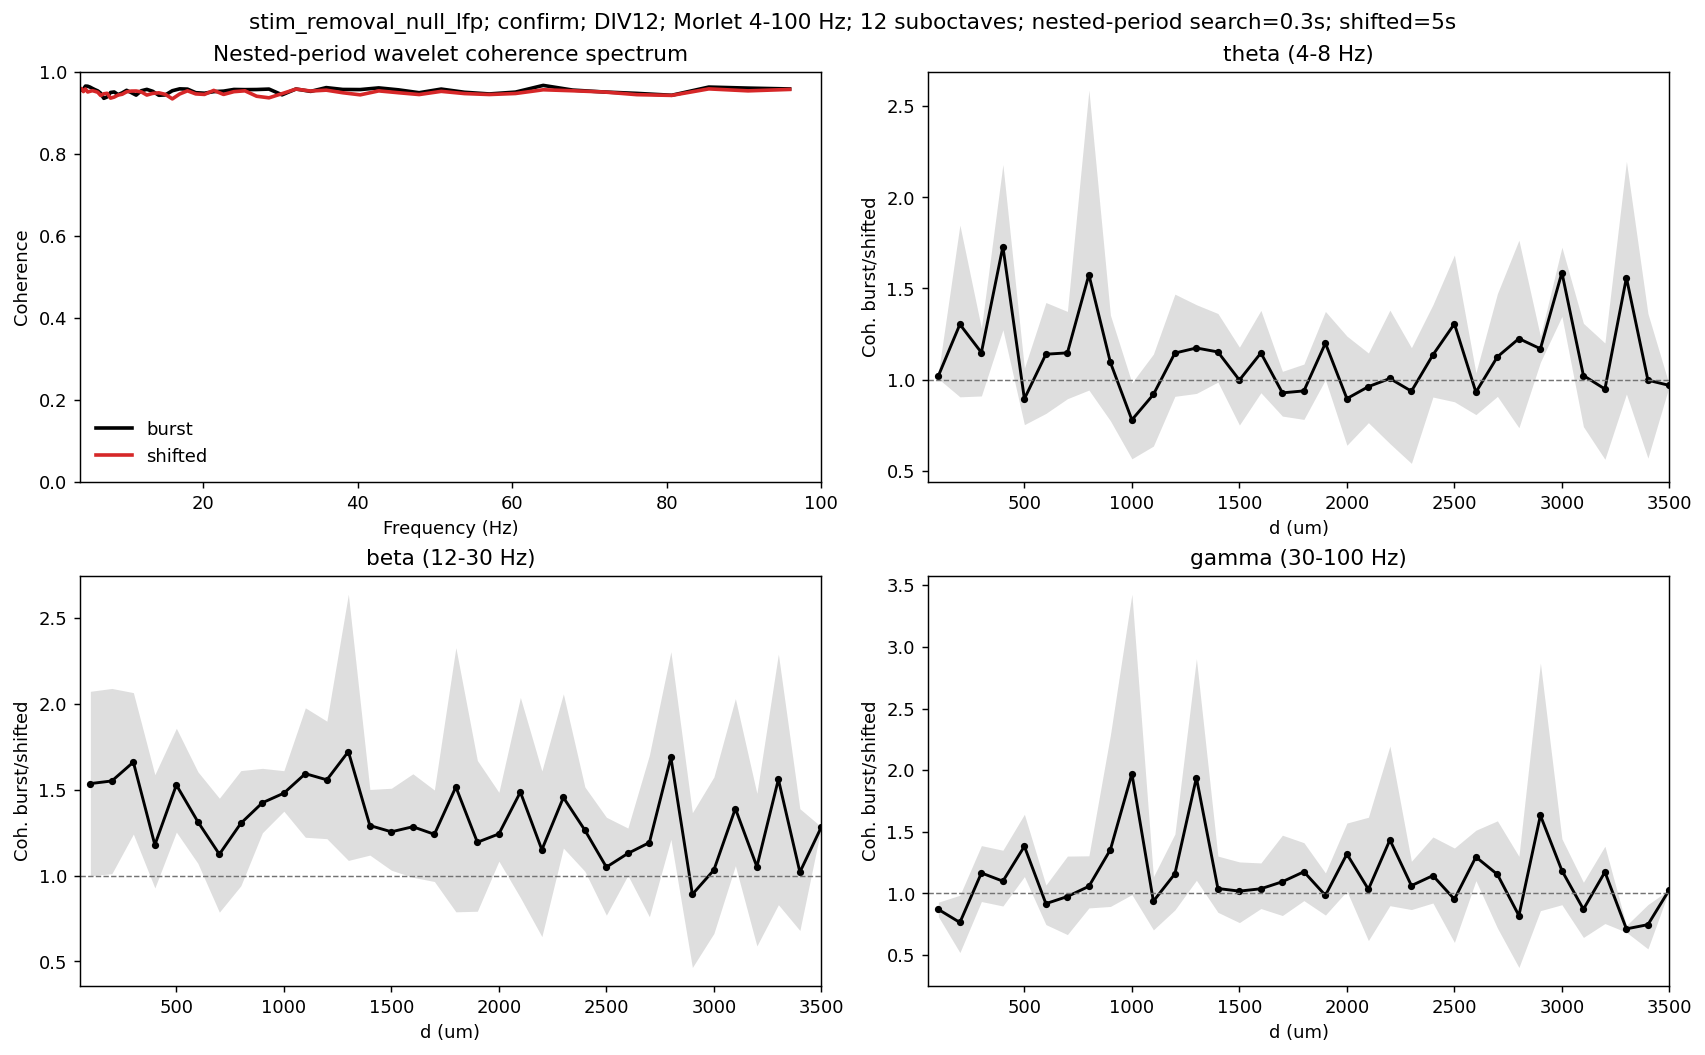

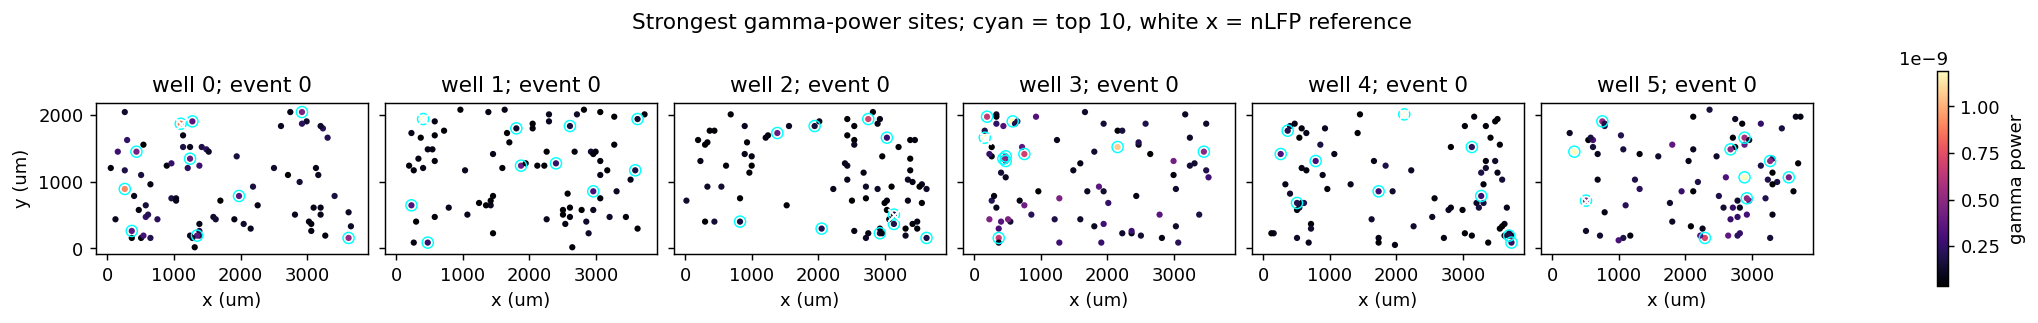

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

ax = axes[0, 0]
if not frequency_summary.empty:
    for condition, group in frequency_summary.groupby("condition"):
        color = "black" if condition == "burst" else "tab:red"
        ax.plot(group["frequency_hz"], group["coherence_mean"], color=color, lw=2.0, label=condition)
ax.set(title="Nested-period wavelet coherence spectrum", xlabel="Frequency (Hz)", ylabel="Coherence")
ax.set_xlim(WAVELET_LOW_HZ, WAVELET_HIGH_HZ)
ax.set_ylim(0, 1)
ax.legend(frameon=False)

bands = ["theta", "beta", "gamma"]
for ax, band in zip([axes[0, 1], axes[1, 0], axes[1, 1]], bands):
    rel = relative_distance_summary.loc[relative_distance_summary["band"] == band].copy()
    if rel.empty:
        ax.set_axis_off()
        continue
    x = rel["distance_bin_center_um"].to_numpy(float)
    y = rel["coherence_relative_mean"].to_numpy(float)
    lo = rel["coherence_relative_ci_low"].to_numpy(float)
    hi = rel["coherence_relative_ci_high"].to_numpy(float)
    ax.plot(x, y, marker="o", color="black", lw=1.6, ms=3.0)
    ax.fill_between(x, lo, hi, color="0.2", alpha=0.16, linewidth=0)
    ax.axhline(1.0, color="0.45", lw=0.8, ls="--")
    low, high = FREQUENCY_BANDS[band]
    ax.set(title=f"{band} ({low:g}-{high:g} Hz)", xlabel="d (um)", ylabel="Coh. burst/shifted")
    ax.set_xlim(MIN_DISTANCE_UM, MAX_DISTANCE_UM)

fig.suptitle(CACHE_NOTE)
figure_dir = OUTPUT_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "morlet_nested_period_coherence_over_distance.png", dpi=300, bbox_inches="tight")
fig.savefig(figure_dir / "morlet_nested_period_coherence_over_distance.pdf", bbox_inches="tight")
plt.show()

if not gamma_site_power.empty:
    first_events = gamma_site_power.sort_values(["well", "event_idx", "gamma_power_rank"]).groupby("well", as_index=False).first()[["well", "event_idx"]]
    plot_power = gamma_site_power.merge(first_events, on=["well", "event_idx"], how="inner")
    wells = sorted(plot_power["well"].unique())
    fig, axes = plt.subplots(1, len(wells), figsize=(2.6 * len(wells), 2.4), sharex=True, sharey=True, constrained_layout=True)
    if len(wells) == 1:
        axes = [axes]
    vmax = np.nanpercentile(plot_power["gamma_power"], 99)
    vmin = np.nanpercentile(plot_power["gamma_power"], 5)
    for ax, well in zip(axes, wells):
        g = plot_power.loc[plot_power["well"] == well]
        sc = ax.scatter(g["x_um"], g["y_um"], c=g["gamma_power"], s=12, cmap="magma", vmin=vmin, vmax=vmax, linewidths=0)
        top = g.nsmallest(10, "gamma_power_rank")
        ax.scatter(top["x_um"], top["y_um"], facecolors="none", edgecolors="cyan", s=38, linewidths=0.8)
        ref = g.loc[g["is_ref_electrode"].astype(bool)]
        ax.scatter(ref["x_um"], ref["y_um"], marker="x", c="white", s=48, linewidths=1.2)
        ax.set_title(f"well {well}; event {int(g['event_idx'].iloc[0])}")
        ax.set_aspect("equal")
        ax.set_xlabel("x (um)")
    axes[0].set_ylabel("y (um)")
    fig.colorbar(sc, ax=axes, shrink=0.8, label="gamma power")
    fig.suptitle("Strongest gamma-power sites; cyan = top 10, white x = nLFP reference")
    fig.savefig(figure_dir / "morlet_gamma_power_site_diagnostic.png", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / "morlet_gamma_power_site_diagnostic.pdf", bbox_inches="tight")
    plt.show()


## Save Tables

In [10]:
table_dir = OUTPUT_DIR / "tables"
table_dir.mkdir(parents=True, exist_ok=True)
cache_summary.to_csv(table_dir / "cache_summary.csv", index=False)
selected_event_table.to_csv(table_dir / "morlet_selected_events.csv", index=False)
event_distance_coherence.to_csv(table_dir / "morlet_event_distance_coherence.csv", index=False)
condition_distance_summary.to_csv(table_dir / "morlet_condition_distance_summary.csv", index=False)
relative_event_distance.to_csv(table_dir / "morlet_relative_event_distance.csv", index=False)
relative_distance_summary.to_csv(table_dir / "morlet_relative_distance_summary.csv", index=False)
frequency_coherence.to_csv(table_dir / "morlet_frequency_coherence.csv", index=False)
frequency_summary.to_csv(table_dir / "morlet_frequency_summary.csv", index=False)
gamma_site_power.to_csv(table_dir / "morlet_gamma_site_power.csv", index=False)
if STORE_SITE_ROWS and not lfp_site_coherence.empty:
    lfp_site_coherence.to_csv(table_dir / "morlet_site_coherence.csv", index=False)
print(f"Wrote Morlet coherence tables to {table_dir}")


Wrote Morlet coherence tables to /Users/danielrebbin/Documents/GitHub/ephax/outputs/lfp_coherence_distance/tables
